In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
 
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay)
from imblearn.over_sampling import SMOTE
 
import warnings
warnings.filterwarnings('ignore')

In [15]:
print("=" * 55)
print("STEP 1 — DATA SETUP & EDA")
print("=" * 55)
 
df = pd.read_csv('fertility.csv')
 
print("\n---- Shape ----")
print(df.shape)
 
print("\n---- Info ----")
df.info()

print("\n---- Describe ----")
print(df.describe())
 
print("\n---- Target Distribution ----")
print(df['output'].value_counts())

STEP 1 — DATA SETUP & EDA

---- Shape ----
(100, 10)

---- Info ----
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   season                 100 non-null    float64
 1   age                    100 non-null    float64
 2   childish-disease       100 non-null    int64  
 3   trauma                 100 non-null    int64  
 4   surgical-intervention  100 non-null    int64  
 5   fevers                 100 non-null    int64  
 6   alcoholic              100 non-null    float64
 7   smoking                100 non-null    int64  
 8   sitting                100 non-null    float64
 9   output                 100 non-null    object 
dtypes: float64(4), int64(5), object(1)
memory usage: 7.9+ KB

---- Describe ----
           season         age  childish-disease      trauma  \
count  100.000000  100.000000        100.000000  100.00000

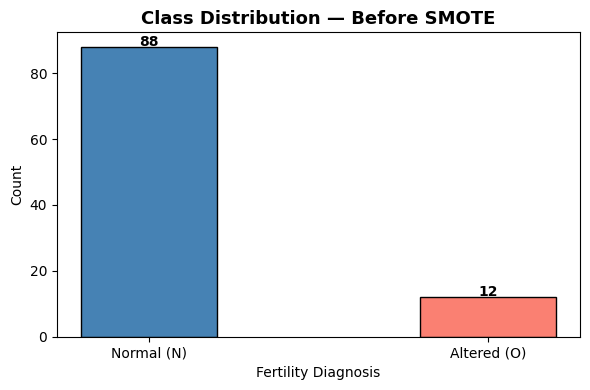

Saved: graph1_class_distribution_before_smote.png

── Feature Variances (justifies PCA — low-variance features add noise) ──
season                   0.6348
age                      0.0147
childish-disease         0.1142
trauma                   0.2489
surgical-intervention    0.2524
fevers                   0.3373
alcoholic                0.0281
smoking                  0.6540
sitting                  0.0347
dtype: float64


In [16]:
fig, ax = plt.subplots(figsize=(6, 4))
counts = df['output'].value_counts()
ax.bar(counts.index, counts.values,
       color=['steelblue', 'salmon'], edgecolor='black', width=0.4)
ax.set_title('Class Distribution — Before SMOTE', fontsize=13, fontweight='bold')
ax.set_xlabel('Fertility Diagnosis')
ax.set_ylabel('Count')
for i, (label, val) in enumerate(counts.items()):
    ax.text(i, val + 0.3, str(val), ha='center', fontweight='bold')
ax.set_xticks([0, 1])
ax.set_xticklabels(['Normal (N)', 'Altered (O)'])
plt.tight_layout()
plt.savefig('graph1_class_distribution_before_smote.png', dpi=150)
plt.show()
print("Saved: graph1_class_distribution_before_smote.png")
 
# ── Print feature variances (justify PCA) ──
print("\n── Feature Variances (justifies PCA — low-variance features add noise) ──")
print(df.drop(columns='output').var().round(4))
 